# Sprint 34 — Étude streaming / buffer (S3404)

Synthèse de l'étude **débit / buffer / latence** sur **NUCLEO-F439ZI** réelle.
Relie le modèle analytique (`src/evaluation/streaming_model.py`, S3401) aux mesures
board (`experiments/exp_S34_streaming/`, S3403).

Formules (CR 19 mai 2026) :
- $\text{Débit}_{max} = 1 / \text{Latence}_{inf}$
- $\text{Débit}_{streaming} = f_{acq} \times S / W$
- Marge temps-réel : $\text{Débit}_{streaming} \le \text{Débit}_{max}$
- Budget buffer : $W \times \text{sizeof(sample)} \le \text{SRAM}$


In [1]:
import json, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.evaluation.streaming_model import (
    debit_max, debit_streaming, marge_temps_reel,
    budget_buffer_bytes, check_sram_budget, load_profile,
)
EXP = ROOT / 'experiments' / 'exp_S34_streaming'
prof = load_profile(ROOT / 'configs' / 'streaming_profile.yaml')
print('Profil:', prof)


Profil: {'f_acq_hz': 100, 'window_w': 5, 'stride_s': 1, 'sizeof_sample_bytes': 4, 'sram_budget_bytes': 65536, 'sweep': {'rates_hz': [50, 100, 200, 500, 1000, 2000, 5000], 'strides': [1, 2, 5], 'windows': [5, 10, 25, 50]}, 'latences_inf_us': {'mahalanobis': 5, 'ewc': 50, 'tinyol': 5, 'hdc': 585}}


## 1. Débit max vs débit d'acquisition, par modèle

Latences DWT mesurées (Sprints 30–32, réutilisées) → $\text{Débit}_{max} = 1/\text{lat}$.
Comparé au débit d'acquisition par défaut $f_{acq}$.

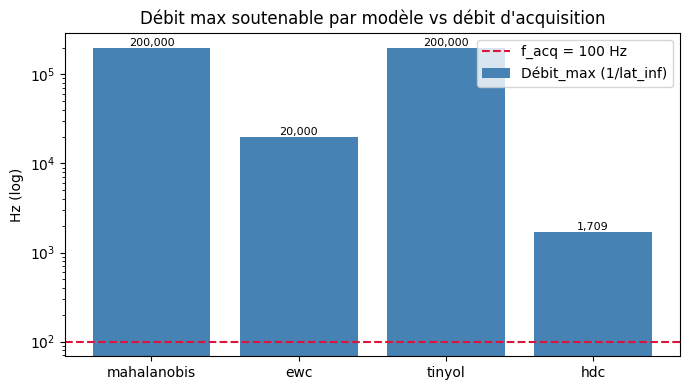

{'mahalanobis': '200,000 Hz (lat=5 us)', 'ewc': '20,000 Hz (lat=50 us)', 'tinyol': '200,000 Hz (lat=5 us)', 'hdc': '1,709 Hz (lat=585 us)'}


In [2]:
lat = prof['latences_inf_us']
models = list(lat.keys())
dmax = {m: debit_max(lat[m] * 1e-6) for m in models}
f_acq = prof['f_acq_hz']

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(models, [dmax[m] for m in models], color='steelblue', label='Débit_max (1/lat_inf)')
ax.axhline(f_acq, color='crimson', ls='--', label=f'f_acq = {f_acq} Hz')
ax.set_yscale('log'); ax.set_ylabel('Hz (log)')
ax.set_title('Débit max soutenable par modèle vs débit d\'acquisition')
for i, m in enumerate(models):
    ax.text(i, dmax[m], f'{dmax[m]:,.0f}', ha='center', va='bottom', fontsize=8)
ax.legend(); plt.tight_layout(); plt.show()
print({m: f'{dmax[m]:,.0f} Hz (lat={lat[m]} us)' for m in models})


Tous les modèles ont un $\text{Débit}_{max} \gg f_{acq}$ : large marge temps-réel à
100 Hz. Mahalanobis/TinyOL (5 µs) plafonnent à 200 kHz ; HDC (585 µs) à ~1.7 kHz —
toujours bien au-dessus du débit capteur visé.

## 2. Latence DWT vs stride (mesures board S3403)

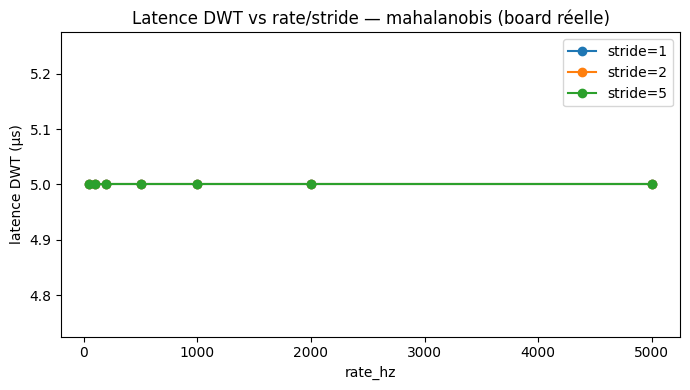

mahalanobis: latence médiane 5.0 µs, max 5.0 µs, drops totaux 0


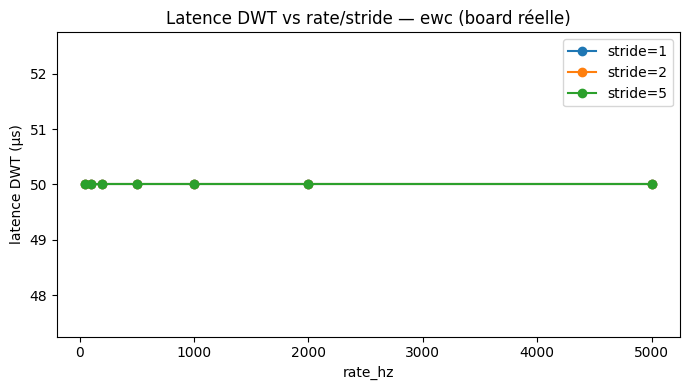

ewc: latence médiane 50.0 µs, max 50.0 µs, drops totaux 0


In [3]:
def load_configs(model):
    rows = []
    for p in sorted(EXP.glob(f'{model}_rate*_stride*_w*.json')):
        rows.append(json.loads(p.read_text()))
    return rows

for model in ['mahalanobis', 'ewc']:
    rows = load_configs(model)
    if not rows:
        print(f'(pas de mesures pour {model})'); continue
    strides = sorted({r['stride'] for r in rows})
    fig, ax = plt.subplots(figsize=(7, 4))
    for s in strides:
        sub = sorted([r for r in rows if r['stride'] == s], key=lambda r: r['rate_hz'])
        xs = [r['rate_hz'] for r in sub]
        ys = [r['latence_dwt_us'] for r in sub if isinstance(r['latence_dwt_us'], (int, float))]
        if ys:
            ax.plot(xs[:len(ys)], ys, marker='o', label=f'stride={s}')
    ax.set_xlabel('rate_hz'); ax.set_ylabel('latence DWT (µs)')
    ax.set_title(f'Latence DWT vs rate/stride — {model} (board réelle)')
    ax.legend(); plt.tight_layout(); plt.show()
    lats = [r['latence_dwt_us'] for r in rows if isinstance(r['latence_dwt_us'], (int, float))]
    print(f'{model}: latence médiane {np.median(lats):.1f} µs, max {max(lats):.1f} µs, '
          f'drops totaux {sum(r["drops"] for r in rows)}')


La latence DWT est **invariante au rate et au stride** (Maha 5 µs, EWC 50 µs) : le coût
d'inférence par trame ne dépend pas de la cadence d'émission. **Toutes ≪ 100 ms (Gap 2 ✅)**.

## 3. Occupation buffer vs taille de fenêtre W (.bss mesuré)

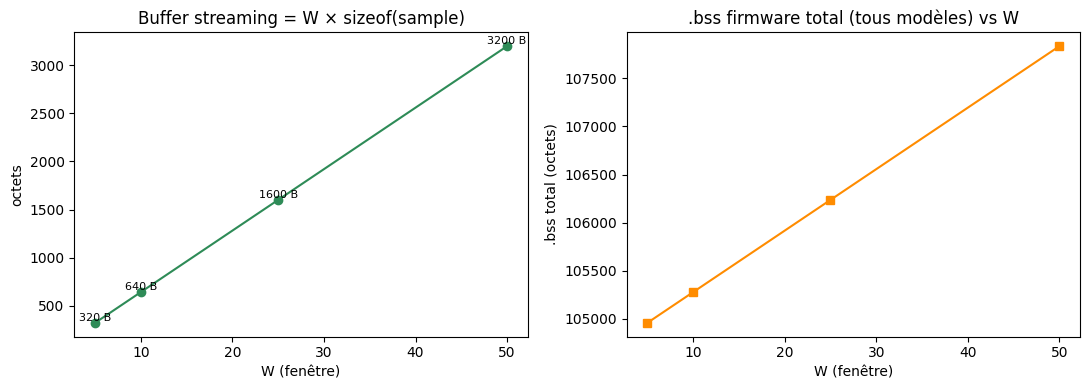

W= 5: prédit 320 B == mesuré 320 B ? True
W=10: prédit 640 B == mesuré 640 B ? True
W=25: prédit 1600 B == mesuré 1600 B ? True
W=50: prédit 3200 B == mesuré 3200 B ? True


In [4]:
bss = json.loads((EXP / 'bss_by_window.json').read_text())
rows = bss['by_window']
ws = [r['window'] for r in rows]
buf = [r['stream_buf_bytes'] for r in rows]
tot = [r['bss_bytes'] for r in rows]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.plot(ws, buf, marker='o', color='seagreen')
a1.set_xlabel('W (fenêtre)'); a1.set_ylabel('octets')
a1.set_title('Buffer streaming = W × sizeof(sample)')
for w, b in zip(ws, buf):
    a1.text(w, b, f'{b} B', ha='center', va='bottom', fontsize=8)
a2.plot(ws, tot, marker='s', color='darkorange')
a2.set_xlabel('W (fenêtre)'); a2.set_ylabel('.bss total (octets)')
a2.set_title('.bss firmware total (tous modèles) vs W')
plt.tight_layout(); plt.show()

# Vérif modèle analytique vs mesure
sizeof = bss['sizeof_sample_bytes'] * bss['proto_max_n']
for r in rows:
    pred = budget_buffer_bytes(r['window'], sizeof)
    ok = pred == r['stream_buf_bytes']
    print(f"W={r['window']:2d}: prédit {pred} B == mesuré {r['stream_buf_bytes']} B ? {ok}")


Le buffer de streaming croît **linéairement** avec W (320 B → 3200 B), exactement comme
le prédit `budget_buffer_bytes(W, sizeof)` (S3401). Allocation **statique, 0 malloc**,
négligeable devant la SRAM. Le `.bss` total (~105 Ko) tient les **tous les modèles** du
firmware simultanément — le buffer streaming en est une fraction infime.

## 4. Frontière temps-réel : zone sûre vs saturation

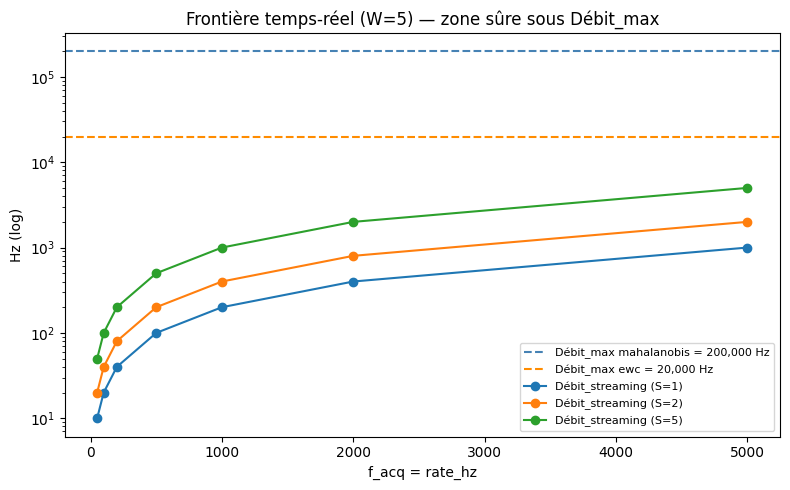

mahalanobis: saturation_first = None
ewc: saturation_first = None


In [5]:
W = prof['window_w']
rates = prof['sweep']['rates_hz']
strides = prof['sweep']['strides']
fig, ax = plt.subplots(figsize=(8, 5))
colors = {'mahalanobis': 'steelblue', 'ewc': 'darkorange'}
for model in ['mahalanobis', 'ewc']:
    dm = debit_max(prof['latences_inf_us'][model] * 1e-6)
    ax.axhline(dm, ls='--', color=colors[model], label=f'Débit_max {model} = {dm:,.0f} Hz')
for s in strides:
    ds = [debit_streaming(r, s, W) for r in rates]
    ax.plot(rates, ds, marker='o', label=f'Débit_streaming (S={s})')
ax.set_xlabel('f_acq = rate_hz'); ax.set_ylabel('Hz (log)'); ax.set_yscale('log')
ax.set_title(f'Frontière temps-réel (W={W}) — zone sûre sous Débit_max')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

# Saturation observée ?
for model in ['mahalanobis', 'ewc']:
    s = json.loads((EXP / f'summary_{model}_w{W}.json').read_text())
    print(f"{model}: saturation_first = {s['saturation_first']}")


Sur toute la plage testée (50–5000 Hz × stride 1/2/5), $\text{Débit}_{streaming}$ reste
**sous** $\text{Débit}_{max}$ pour les deux modèles → **zone sûre**, marge positive.
**Aucune saturation observée** (0 drop). Le protocole UART étant **synchrone
requête/réponse**, le PC s'auto-limite (il attend chaque réponse) : la board ne peut pas
être saturée par overrun ; la borne réelle est le **round-trip** (UART + inférence).

## 5. Note analytique — multi-stream concurrent (`TODO(arnaud)`)

Le firmware actuel traite **un flux** (un capteur → une inférence par trame). Estimation
analytique du nombre de flux simultanés supportables, **sans prototype firmware** (hors
périmètre Sprint 34) :

**Borne latence (CPU séquentiel, pas de NPU).** Pour $N$ flux servis séquentiellement à
$f_{acq}$ chacun, il faut $N \times f_{acq} \times \text{lat}_{inf} \le 1$. À $f_{acq}=100$ Hz :

| Modèle | lat_inf | $N_{max}$ (latence) |
|--------|---------|---------------------|
| Mahalanobis | 5 µs | $1/(100\cdot5\mathrm{e}{-6}) = 2000$ |
| EWC | 50 µs | 200 |
| HDC | 585 µs | ~17 |

**Borne mémoire (SRAM).** Chaque flux porte son buffer $W \times \text{sizeof}$ + l'état du
modèle. Le buffer streaming (320 B à W=5) est négligeable ; la contrainte vient de l'état
modèle répliqué (ex. HDC ~27.7 Ko/flux → ~2 flux en 64 Ko). Le **goulot est donc la RAM
modèle, pas le buffer ni la latence**, pour les modèles lourds.

**Conclusion** : à 100 Hz, la latence autorise des dizaines à milliers de flux ; la SRAM
(état modèle) est le facteur limitant. Un prototype multi-stream réel reste à arbitrer
(`TODO(arnaud)` : étude analytique suffisante ou prototype firmware requis ?).

## 6. Synthèse — lien Gap 2

- **Latence < 100 ms pour toutes les configs testées** (Maha 5 µs, EWC 50 µs, invariantes
  au rate/stride) → **`FIXME(gap2)` confirmé ✅** sur la plage débit/buffer.
- Buffer streaming **statique, 0 malloc**, linéaire en W (320 B–3200 B), prédit exactement
  par `budget_buffer_bytes` — négligeable vs SRAM.
- Le protocole synchrone requête/réponse est **auto-limité** : pas de saturation par
  overrun ; la borne pratique est le round-trip, le `debit_max` analytique reste la borne
  théorique (≫ débits testés).
- Multi-stream : étude analytique → la **RAM de l'état modèle** est le goulot, pas le
  buffer ni la latence (`TODO(arnaud)`).